# EDA dos datasets de RSL

Análise exploratória dos 8 temas de Revisões Sistemáticas em `slr-sentence-embedding-master/bibs/`,
carregados pelo módulo `llm_slr.data`. A paridade com o loader legado é checada em
`llm_slr/tests/test_parity.py`.

O que quero olhar aqui:

1. tamanho e desbalanceamento de cada tema, que é o que motiva usar recall e WSS@95;
2. distribuição temporal e as fronteiras dos folds do `YearsSplit`;
3. sanidade dos folds, ou seja, tamanho de treino e teste e presença de positivos no teste.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from llm_slr.config import N_SPLITS, THEMES
from llm_slr.data.loader import load_theme
from llm_slr.data.splits import YearsSplit

# cores dos gráficos: incluído em destaque, excluído em cinza
C_INCLUDED = '#2a78d6'
C_EXCLUDED = '#c3c2b7'
C_SURFACE = '#fcfcfb'
C_INK = '#0b0b0b'
C_MUTED = '#898781'
C_GRID = '#e1e0d9'

plt.rcParams.update({
    'figure.facecolor': C_SURFACE, 'axes.facecolor': C_SURFACE,
    'text.color': C_INK, 'axes.edgecolor': C_MUTED,
    'axes.labelcolor': C_MUTED, 'xtick.color': C_MUTED, 'ytick.color': C_MUTED,
    'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
})

datasets = {theme: load_theme(theme) for theme in sorted(THEMES)}

## 1. Resumo por tema

Todos os temas são desbalanceados, com minoria de incluídos. É por isso que a baseline calibra o
threshold por recall e que os experimentos com LLMs usam WSS@95.

In [2]:
summary = pd.DataFrame([
    {
        'tema': theme,
        'artigos': len(arts),
        'incluídos': sum(a.label for a in arts),
        'excluídos': sum(1 - a.label for a in arts),
        '% incluídos': round(100 * sum(a.label for a in arts) / len(arts), 1),
        'ano mín': min(a.year for a in arts),
        'ano máx': max(a.year for a in arts),
    }
    for theme, arts in datasets.items()
]).set_index('tema')
summary

,artigos,incluídos,excluídos,% incluídos,ano mín,ano máx
tema,,,,,,
games,223,84,139,37.7,1963,2009
illiterate,247,36,211,14.6,1973,2014
mdwe,95,30,65,31.6,1999,2010
ontologies,491,47,444,9.6,1612,2018
pair,264,74,190,28.0,1998,2007
slr,37,23,14,62.2,2003,2007
testing,355,30,325,8.5,1504,2018
xbi,276,39,237,14.1,1202,2018


Sobre a qualidade dos dados: alguns temas têm anos claramente inválidos nos metadados, como
1202 em `xbi`, 1504 em `testing` e 1612 em `ontologies`. Como o split é por ordem de ano, esses
artigos caem no começo do bloco de treino e não chegam aos blocos de teste. Mesmo assim vale
registrar a limitação na dissertação.

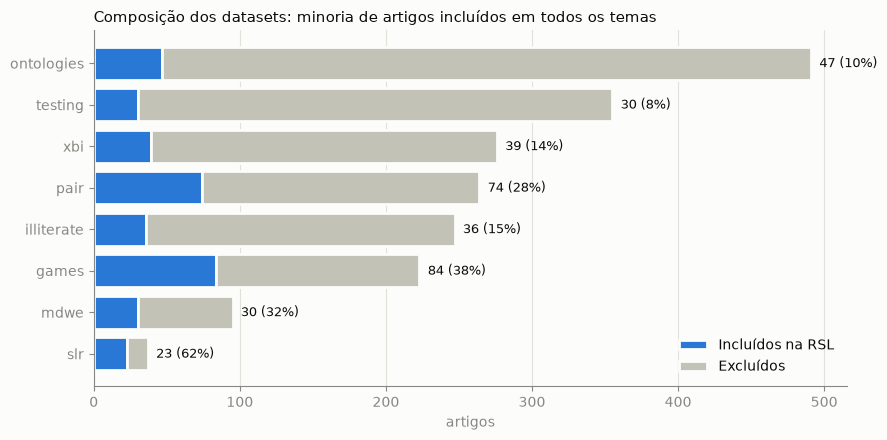

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = summary.sort_values('artigos').index
inc = summary.loc[order, 'incluídos']
exc = summary.loc[order, 'excluídos']

ax.barh(order, inc, color=C_INCLUDED, label='Incluídos na RSL',
        edgecolor=C_SURFACE, linewidth=2)
ax.barh(order, exc, left=inc, color=C_EXCLUDED, label='Excluídos',
        edgecolor=C_SURFACE, linewidth=2)
for theme in order:
    n, i = summary.loc[theme, 'artigos'], summary.loc[theme, 'incluídos']
    ax.annotate(f"{i} ({100 * i / n:.0f}%)", (n, theme), xytext=(6, 0),
                textcoords='offset points', va='center', fontsize=9, color=C_INK)

ax.set_title('Composição dos datasets: minoria de artigos incluídos em todos os temas',
             loc='left', fontsize=11, color=C_INK)
ax.set_xlabel('artigos')
ax.grid(axis='y', visible=False)
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

## 2. Distribuição temporal e fronteiras dos folds

As linhas tracejadas marcam o início do bloco de teste de cada um dos 3 folds do `YearsSplit`.
À esquerda da linha está a revisão original, que serve de treino e de fonte dos exemplos
few-shot; à direita, os artigos novos da atualização simulada.

O eixo x foi recortado em 1990 para ficar legível. Os poucos artigos anteriores, incluindo os de
ano inválido, caem sempre no treino.

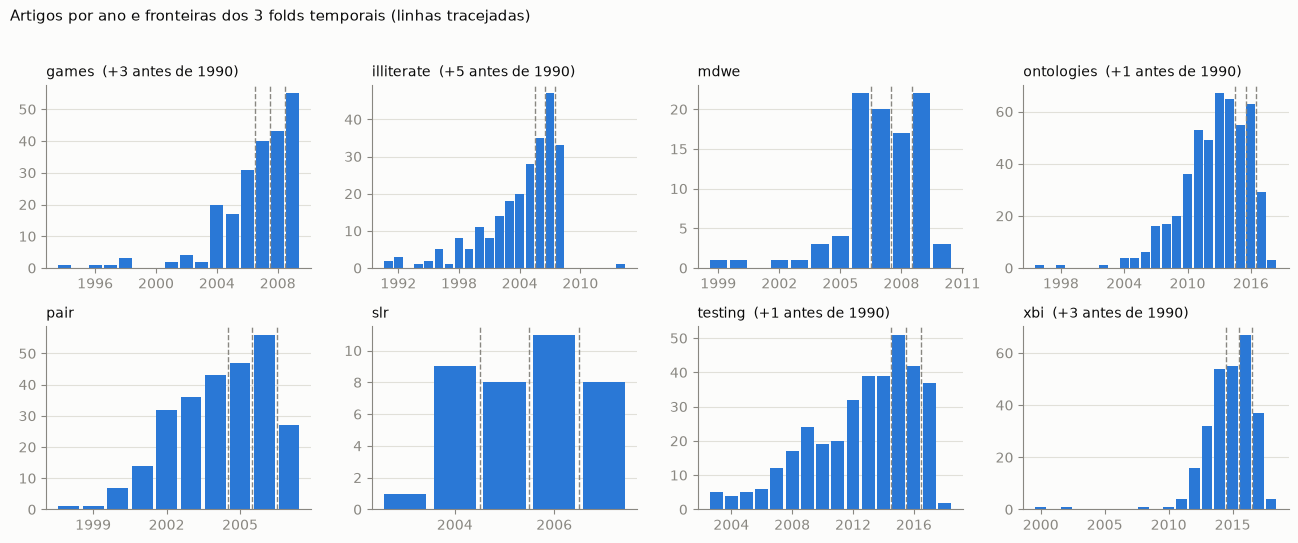

In [4]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(2, 4, figsize=(13, 5.5), sharey=False)

for ax, (theme, arts) in zip(axes.flat, datasets.items()):
    years = [a.year for a in arts]
    counts = pd.Series(years).value_counts().sort_index()
    visible = counts[counts.index >= 1990]
    ax.bar(visible.index, visible.values, color=C_INCLUDED, width=0.85)

    folds = YearsSplit(n_split=N_SPLITS, years=years).split(arts)
    for _, test in folds:
        ax.axvline(years[test[0]] - 0.5, color=C_MUTED, linestyle='--', linewidth=1)

    hidden = sum(v for y, v in counts.items() if y < 1990)
    label = f'{theme}' + (f'  (+{hidden} antes de 1990)' if hidden else '')
    ax.set_title(label, loc='left', fontsize=10, color=C_INK)
    ax.grid(axis='x', visible=False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

fig.suptitle('Artigos por ano e fronteiras dos 3 folds temporais (linhas tracejadas)',
             x=0.005, ha='left', fontsize=11, color=C_INK)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 3. Sanidade dos folds

Para cada fold: tamanho do treino, que é o histórico disponível para few-shot, tamanho do teste,
que são os artigos da atualização, e quantos positivos há no teste. Fold sem positivo no teste
não permite calcular recall, o que atrapalha na hora de ler as médias por tema.

In [5]:
rows = []
for theme, arts in datasets.items():
    years = [a.year for a in arts]
    folds = YearsSplit(n_split=N_SPLITS, years=years).split(arts)
    for k, (train, test) in enumerate(folds, start=1):
        test_arts = [arts[i] for i in test]
        train_arts = [arts[i] for i in train]
        rows.append({
            'tema': theme, 'fold': k,
            'treino': len(train_arts),
            'positivos treino': sum(a.label for a in train_arts),
            'teste': len(test_arts),
            'positivos teste': sum(a.label for a in test_arts),
            'anos teste': f"{min(a.year for a in test_arts)}–{max(a.year for a in test_arts)}",
        })

folds_df = pd.DataFrame(rows).set_index(['tema', 'fold'])
folds_df

treino  positivos treino  teste  positivos teste anos teste
tema       fold                                                             
games      1        168                64     55               20  2009–2009
           2        125                41     43               23  2008–2008
           3         85                26     40               15  2007–2007
illiterate 1        213                31     34                5  2008–2014
           2        166                22     47                9  2007–2007
           3        131                18     35                4  2006–2006
mdwe       1         70                20     25               10  2009–2010
           2         53                12     17                8  2008–2008
           3         33                 5     20                7  2007–2007
ontologies 1        459                42     32                5  2017–2018
           2        396                35     63                7  2016–2016
           3        341                32     55                3  2015–2015
pair       1        237                64     27               10  2007–2007
           2        181                46     56               18  2006–2006
           3        134                31     47               15  2005–2005
slr        1         29                18      8                5  2007–2007
           2         18                11     11                7  2006–2006
           3         10                 7      8                4  2005–2005
testing    1        316                26     39                4  2017–2018
           2        274                24     42                2  2016–2016
           3        223                21     51                3  2015–2015
xbi        1        235                31     41                8  2017–2018
           2        168                25     67                6  2016–2016
           3        113                17     55                8  2015–2015

## O que ficou

- Loader e splits batem com o legado, com os testes de unidade e de paridade passando, então a
  comparação fold a fold com a baseline se sustenta.
- O desbalanceamento é severo em quase todos os temas, o que torna obrigatórias as métricas
  orientadas a recall (recall, missed e WSS@95). F1 sozinho seria enganoso aqui.
- Os 24 folds têm positivos no bloco de teste, sendo o mínimo 2 em `testing`. Recall é calculável
  em todos, mas onde há pouquíssimos positivos a variância é alta, então convém reportar
  intervalos e não só médias.